# Drug Prediction using Machine Learning

In [1]:
# Importing Pandas for data analysis and manipulation
import pandas as pd

# Importing NumPy for numerical operations
import numpy as np

# Importing Matplotlib for data visualization
import matplotlib.pyplot as plt

# Importing Seaborn for statistical data visualization
import seaborn as sns

# Loading the training dataset
train = pd.read_csv("/Users/keva/Downloads/drug_train.csv")

## 1. Replacing the drug names into integer

In [2]:
# replace the drug names to integer
train.replace(to_replace={'drugA': 3, 'drugB': 2, 'drugC': 2, 'drugX': 0, 'DrugY': 1},inplace=True)


/var/folders/9g/ww5kv5d55_d4rwkcn560gz480000gn/T/ipykernel_1810/1961950295.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train.replace(to_replace={'drugA': 3, 'drugB': 2, 'drugC': 2, 'drugX': 0, 'DrugY': 1},inplace=True)


In [3]:
train['Drug'].value_counts()

Drug
1    76
0    43
2    24
3    17
Name: count, dtype: int64

In [4]:
train.head()

,Id,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,79,32,F,LOW,NORMAL,10.840,0
1,197,52,M,NORMAL,HIGH,9.894,0
2,38,39,F,NORMAL,NORMAL,9.709,0
3,24,33,F,LOW,HIGH,33.486,1
4,122,34,M,NORMAL,HIGH,22.456,1


## Replacing BP with integer

In [5]:
# replace the BP to integer
train.replace(to_replace={'LOW': 0, 'NORMAL': 1, 'HIGH': 2},inplace=True)

/var/folders/9g/ww5kv5d55_d4rwkcn560gz480000gn/T/ipykernel_1810/2844566262.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train.replace(to_replace={'LOW': 0, 'NORMAL': 1, 'HIGH': 2},inplace=True)


In [6]:
train['BP'].value_counts()

BP
2    62
1    51
0    47
Name: count, dtype: int64

In [7]:
train.head()

,Id,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,79,32,F,0,1,10.840,0
1,197,52,M,1,2,9.894,0
2,38,39,F,1,1,9.709,0
3,24,33,F,0,2,33.486,1
4,122,34,M,1,2,22.456,1


## Replacing Cholesterol with integer

In [8]:
# replace the Cholesterol to integer
train.replace(to_replace={ 'NORMAL': 0,  'HIGH': 1 },inplace=True)

In [9]:
train['Cholesterol'].value_counts()

Cholesterol
2    88
1    72
Name: count, dtype: int64

In [10]:
train.head()

,Id,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,79,32,F,0,1,10.840,0
1,197,52,M,1,2,9.894,0
2,38,39,F,1,1,9.709,0
3,24,33,F,0,2,33.486,1
4,122,34,M,1,2,22.456,1


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           160 non-null    int64  
 1   Age          160 non-null    int64  
 2   Sex          160 non-null    object 
 3   BP           160 non-null    int64  
 4   Cholesterol  160 non-null    int64  
 5   Na_to_K      160 non-null    float64
 6   Drug         160 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 8.9+ KB


## Replacing sex column with integer

In [12]:
# replace Sex with integer

train.replace(to_replace={'F': 0, 'M': 1}, inplace=True)

/var/folders/9g/ww5kv5d55_d4rwkcn560gz480000gn/T/ipykernel_1810/1320853164.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train.replace(to_replace={'F': 0, 'M': 1}, inplace=True)


In [13]:
train['Sex'].value_counts()

Sex
1    83
0    77
Name: count, dtype: int64

In [14]:
train.head()

,Id,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,79,32,0,0,1,10.840,0
1,197,52,1,1,2,9.894,0
2,38,39,0,1,1,9.709,0
3,24,33,0,0,2,33.486,1
4,122,34,1,1,2,22.456,1


## 2. Splitting the dataset

In [15]:
# Importing train_test_split from sklearn

from sklearn.model_selection import train_test_split

X = train.drop(['Sex','Drug'], axis=1)
y = train['Drug']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [16]:
X_train.head()

,Id,Age,BP,Cholesterol,Na_to_K
73,153,72,0,1,14.642
141,52,62,0,1,27.183
69,146,37,0,1,12.006
23,12,43,0,2,15.376
37,139,69,1,2,10.065


In [17]:
# Displaying the shape of training and testing data
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)
X_train.info()
X_train.columns
X_train.head()

X_train shape: (120, 5)
y_train shape: (120,)
X_test shape: (40, 5)
y_test shape: (40,)
<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 73 to 147
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           120 non-null    int64  
 1   Age          120 non-null    int64  
 2   BP           120 non-null    int64  
 3   Cholesterol  120 non-null    int64  
 4   Na_to_K      120 non-null    float64
dtypes: float64(1), int64(4)
memory usage: 5.6 KB


,Id,Age,BP,Cholesterol,Na_to_K
73,153,72,0,1,14.642
141,52,62,0,1,27.183
69,146,37,0,1,12.006
23,12,43,0,2,15.376
37,139,69,1,2,10.065



# Classification

Classification is a supervised machine learning technique used to assign
data points to predefined classes.

In this project, multiple classification algorithms are implemented and
evaluated to identify the best-performing model for predicting the target
variable.

The following classifiers are used:

1. Logistic Regression
2. XGBoost Classifier
3. Decision Tree Classifier
4. Random Forest Classifier
5. Gradient Boosting Classifier
6. K-Nearest Neighbors (KNN)

## 1. Logistic Regression

In [18]:
# Importing Logistic Regression
from sklearn.linear_model import LogisticRegression

In [19]:
# Creating Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

In [20]:
log_reg.fit(X_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
# Predicting the drug for test data
y_pred = log_reg.predict(X_test)

# Predicting probabilities
y_prob = log_reg.predict_proba(X_test)

## 2. XGBoost

In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

prob = xgb.predict_proba(X_test)
pred = xgb.predict(X_test)

## 3. Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

prob = dt.predict_proba(X_test)
pred = dt.predict(X_test)

## 4. Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

prob = rf.predict_proba(X_test)
pred = rf.predict(X_test)

pred

array([3, 1, 2, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 3, 1, 1, 1, 3, 3, 1, 2, 1, 3, 2])

## 5. Gradient Boosting

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

prob = gb.predict_proba(X_test)
pred = gb.predict(X_test)

pred

array([3, 1, 2, 1, 0, 2, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 3, 1, 1, 1, 3, 3, 1, 2, 1, 3, 2])

## 6.KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

prob = knn.predict_proba(X_test)
pred = knn.predict(X_test)

pred

array([0, 0, 2, 1, 0, 0, 1, 0, 1, 0, 2, 0, 2, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 2, 2, 1, 3, 1, 2, 0, 1, 1, 1, 1, 3, 1, 0, 1, 1, 0])

# MODEL EVALUATION

# Logistic Regression

In [34]:
# Import required evaluation metrics
# To generate classification report

from sklearn.metrics import classification_report

# For plotting confusion matrix
from sklearn.metrics import confusion_matrix

# For calculating the accuracy of the model
from sklearn.metrics import accuracy_score

# To plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

# For Plotting the ROC curve
from sklearn.metrics import roc_curve

In [37]:
models = {
    "Logistic Regression": log_reg,
    "XGBoost": xgb,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "KNN": knn
}

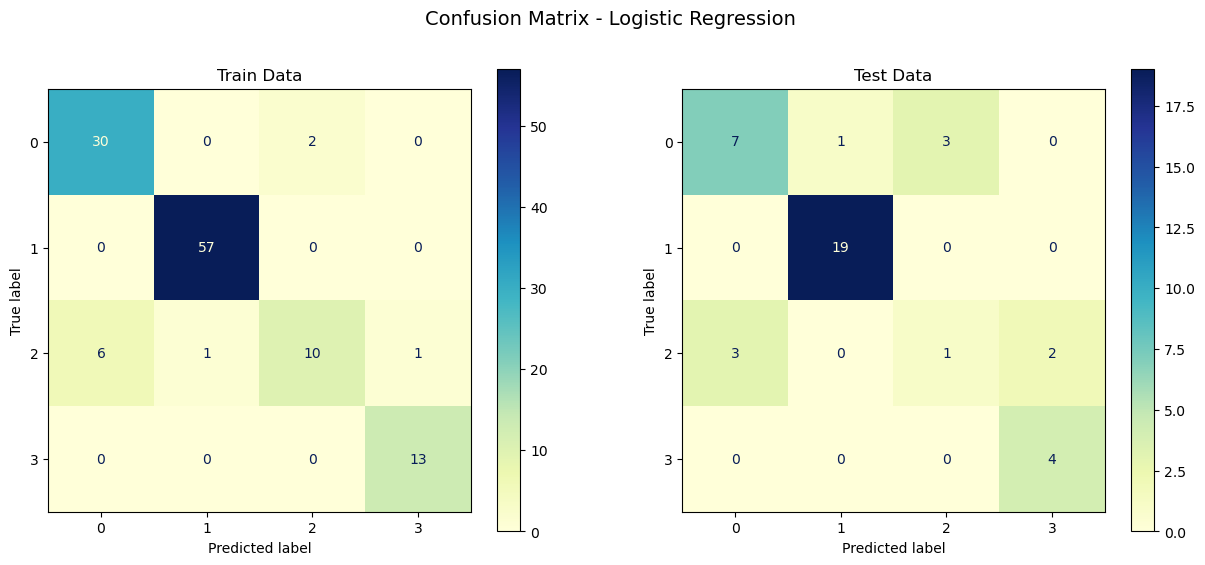

In [39]:
# Predict train and test labels for Logistic Regression

y_train_pred_count = log_reg.predict(X_train)
y_test_pred_count = log_reg.predict(X_test)

# Create confusion matrices for train and test data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax1)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax2)
ax1.set_title('Train Data', size=12)
ax2.set_title('Test Data', size=12)
ax1.grid(False)
ax2.grid(False)
plt.suptitle('Confusion Matrix - Logistic Regression', size=14)
plt.show()

In [40]:
# Calculate the accuracy of Logistic Regression on test data

print("Accuracy score for test data using Logistic Regression is:", accuracy_score(y_test, y_test_pred_count))

Accuracy score for test data using Logistic Regression is: 0.775


In [41]:
# Generate classification report for Logistic Regression

train_report = classification_report(y_train, y_train_pred_count)
test_report = classification_report(y_test, y_test_pred_count)
print("Train Data Report")
print(train_report)
print("Test Data Report")
print(test_report)

Train Data Report
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        32
           1       0.98      1.00      0.99        57
           2       0.83      0.56      0.67        18
           3       0.93      1.00      0.96        13

    accuracy                           0.92       120
   macro avg       0.89      0.87      0.88       120
weighted avg       0.91      0.92      0.91       120

Test Data Report
              precision    recall  f1-score   support

           0       0.70      0.64      0.67        11
           1       0.95      1.00      0.97        19
           2       0.25      0.17      0.20         6
           3       0.67      1.00      0.80         4

    accuracy                           0.78        40
   macro avg       0.64      0.70      0.66        40
weighted avg       0.75      0.78      0.76        40



Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.64      0.67        11
           1       0.95      1.00      0.97        19
           2       0.25      0.17      0.20         6
           3       0.67      1.00      0.80         4

    accuracy                           0.78        40
   macro avg       0.64      0.70      0.66        40
weighted avg       0.75      0.78      0.76        40



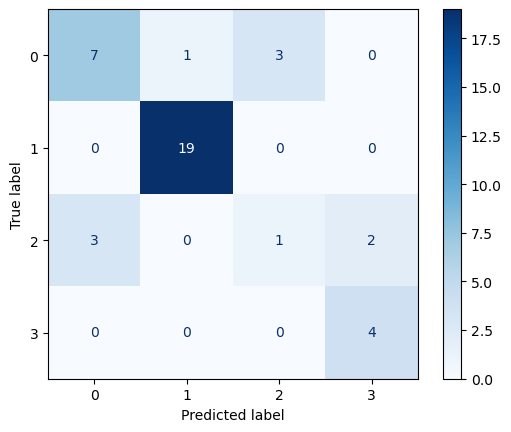

In [42]:
# Display classification report and confusion matrix for Logistic Regression
print("Classification Report:\n", classification_report(y_test, y_test_pred_count))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap="Blues")
plt.show()

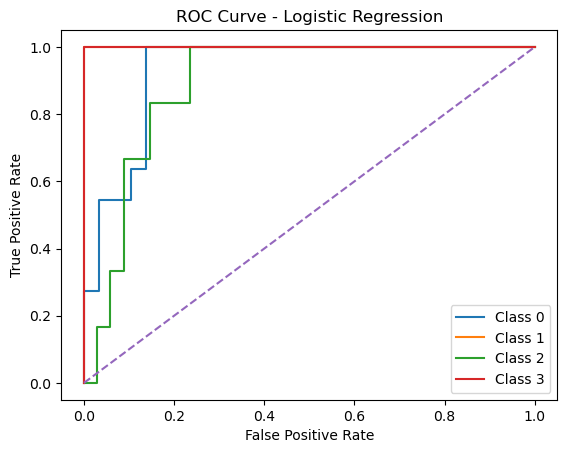

In [80]:
# Predict probability for each class for Logistic Regression
y_test_prob = log_reg.predict_proba(X_test)

# Plot ROC curve for each drug class
for i in range(y_test_prob.shape[1]):
    y_test_class = (y_test == i).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_class, y_test_prob[:, i])
    plt.plot(fpr, tpr, label='Class {}'.format(i))

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

# 2. XGBoost

In [45]:
# Predict train and test labels for XGBoost
y_train_pred_count = xgb.predict(X_train)
y_test_pred_count = xgb.predict(X_test)

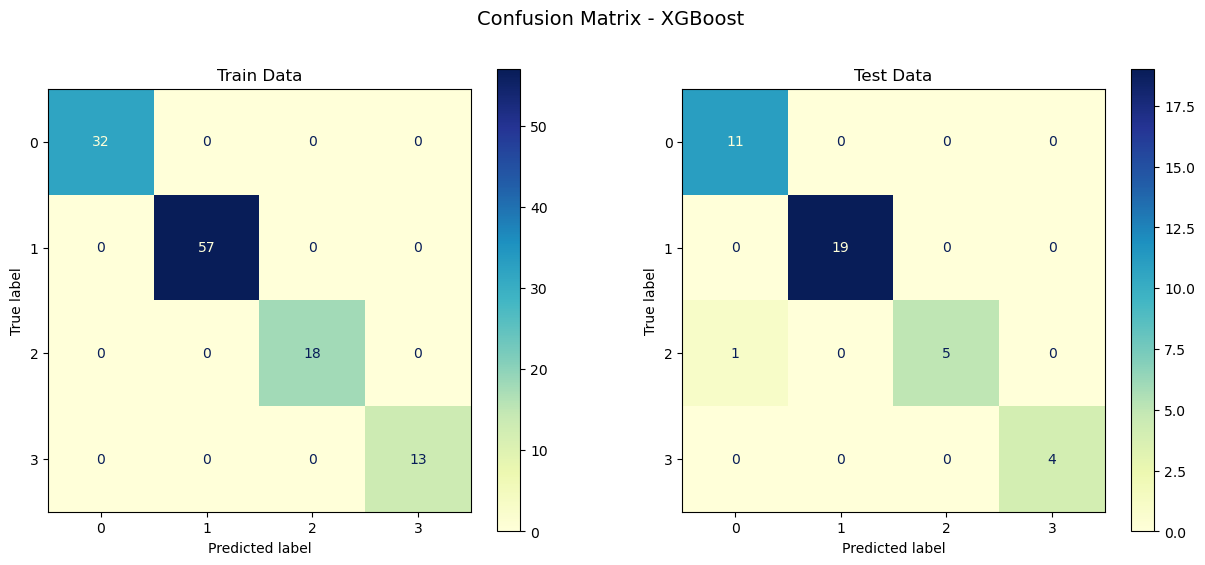

In [46]:
# Predict train and test labels for XGBoost
y_train_pred_count = xgb.predict(X_train)
y_test_pred_count = xgb.predict(X_test)

# Create confusion matrices for train and test data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax1)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax2)
ax1.set_title('Train Data', size=12)
ax2.set_title('Test Data', size=12)
ax1.grid(False)
ax2.grid(False)
plt.suptitle('Confusion Matrix - XGBoost', size=14)
plt.show()

In [47]:
# Calculate the accuracy of XGBoost on test data
print("Accuracy score for test data using XGBoost is:", accuracy_score(y_test, y_test_pred_count))

Accuracy score for test data using XGBoost is: 0.975


In [48]:
# Generate classification report for XGBoost
train_report = classification_report(y_train, y_train_pred_count)
test_report = classification_report(y_test, y_test_pred_count)

print("Train Data Report")
print(train_report)

print("Test Data Report")
print(test_report)

Train Data Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        13

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Test Data Report
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      1.00      1.00        19
           2       1.00      0.83      0.91         6
           3       1.00      1.00      1.00         4

    accuracy                           0.97        40
   macro avg       0.98      0.96      0.97        40
weighted avg       0.98      0.97      0.97        40



Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      1.00      1.00        19
           2       1.00      0.83      0.91         6
           3       1.00      1.00      1.00         4

    accuracy                           0.97        40
   macro avg       0.98      0.96      0.97        40
weighted avg       0.98      0.97      0.97        40



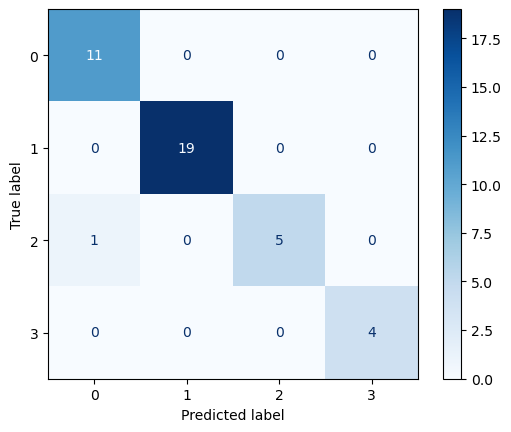

In [49]:
# Display classification report and confusion matrix for XGBoost
print("Classification Report:\n", classification_report(y_test, y_test_pred_count))
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test, cmap="Blues")
plt.show()

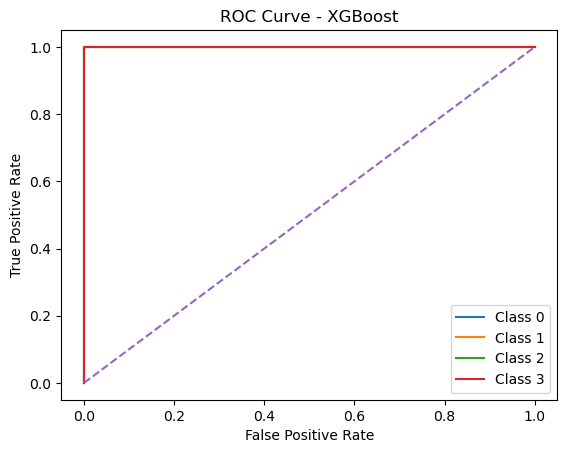

In [79]:
# Predict probability for each class for XGBoost
y_test_prob = xgb.predict_proba(X_test)

# Plot ROC curve for each drug class
for i in range(y_test_prob.shape[1]):
    y_test_class = (y_test == i).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_class, y_test_prob[:, i])
    plt.plot(fpr, tpr, label='Class {}'.format(i))

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

# 3. Decision Tree

In [51]:
# Predict train and test labels for Decision Tree
y_train_pred_count = dt.predict(X_train)
y_test_pred_count = dt.predict(X_test)

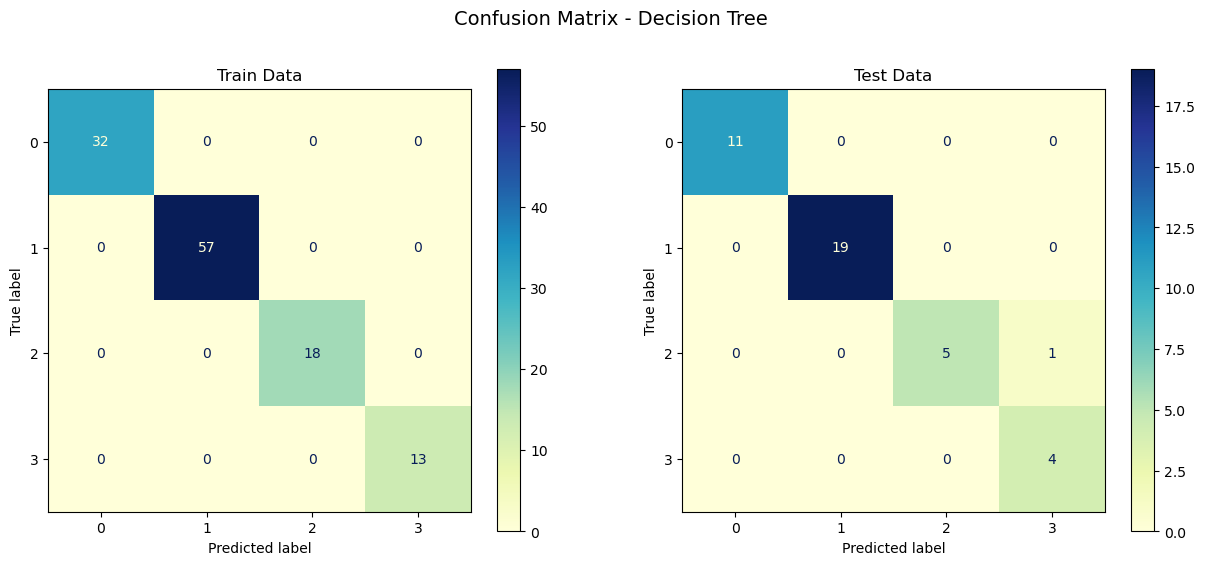

In [52]:
# Predict train and test labels for Decision Tree
y_train_pred_count = dt.predict(X_train)
y_test_pred_count = dt.predict(X_test)

# Create confusion matrices for train and test data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax1)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax2)
ax1.set_title('Train Data', size=12)
ax2.set_title('Test Data', size=12)
ax1.grid(False)
ax2.grid(False)
plt.suptitle('Confusion Matrix - Decision Tree', size=14)
plt.show()

In [53]:
# Calculate the accuracy of Decision Tree on test data
print("Accuracy score for test data using Decision Tree is:", accuracy_score(y_test, y_test_pred_count))

Accuracy score for test data using Decision Tree is: 0.975


In [54]:
# Generate classification report for Decision Tree
train_report = classification_report(y_train, y_train_pred_count)
test_report = classification_report(y_test, y_test_pred_count)

print("Train Data Report")
print(train_report)

print("Test Data Report")
print(test_report)

Train Data Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        13

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Test Data Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19
           2       1.00      0.83      0.91         6
           3       0.80      1.00      0.89         4

    accuracy                           0.97        40
   macro avg       0.95      0.96      0.95        40
weighted avg       0.98      0.97      0.98        40



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19
           2       1.00      0.83      0.91         6
           3       0.80      1.00      0.89         4

    accuracy                           0.97        40
   macro avg       0.95      0.96      0.95        40
weighted avg       0.98      0.97      0.98        40



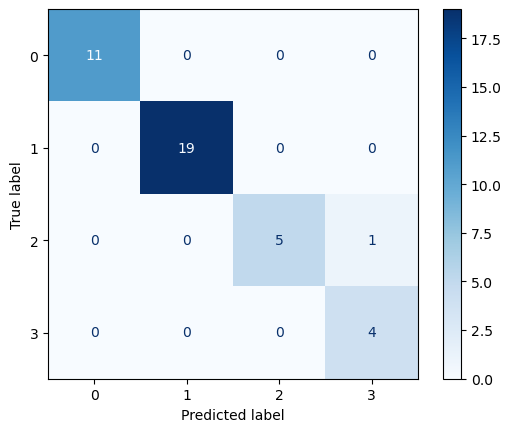

In [55]:
# Display classification report and confusion matrix for Decision Tree
print("Classification Report:\n", classification_report(y_test, y_test_pred_count))
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, cmap="Blues")
plt.show()

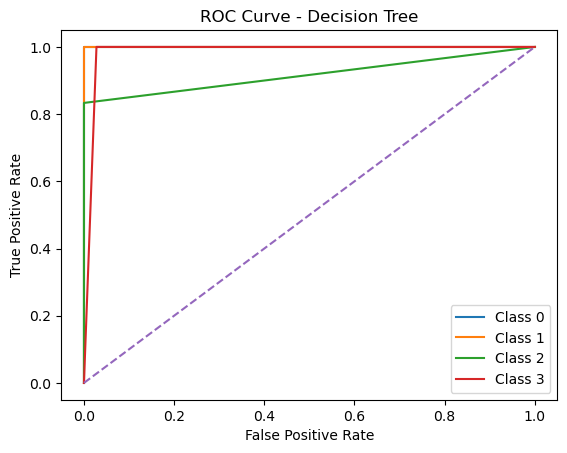

In [78]:
# Predict probability for each class for Decision Tree
y_test_prob = dt.predict_proba(X_test)

# Plot ROC curve for each drug class
for i in range(y_test_prob.shape[1]):
    y_test_class = (y_test == i).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_class, y_test_prob[:, i])
    plt.plot(fpr, tpr, label='Class {}'.format(i))

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()

# 4. Random Forest Classifier

In [57]:
# Predict train and test labels for Random Forest
y_train_pred_count = rf.predict(X_train)
y_test_pred_count = rf.predict(X_test)

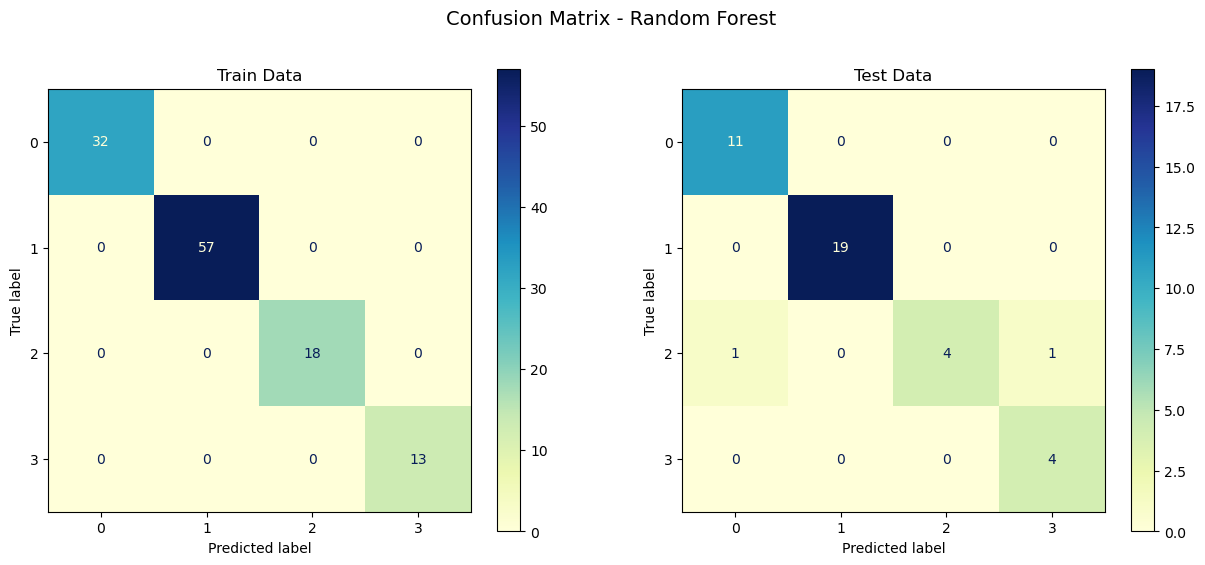

In [58]:
# Create confusion matrices for train and test data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax1)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax2)
ax1.set_title('Train Data', size=12)
ax2.set_title('Test Data', size=12)
ax1.grid(False)
ax2.grid(False)
plt.suptitle('Confusion Matrix - Random Forest', size=14)
plt.show()

In [59]:
# Calculate the accuracy of Random Forest on test data
print("Accuracy score for test data using Random Forest is:", accuracy_score(y_test, y_test_pred_count))

Accuracy score for test data using Random Forest is: 0.95


In [60]:
# Generate classification report for Random Forest
train_report = classification_report(y_train, y_train_pred_count)
test_report = classification_report(y_test, y_test_pred_count)

print("Train Data Report")
print(train_report)

print("Test Data Report")
print(test_report)

Train Data Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        13

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Test Data Report
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      1.00      1.00        19
           2       1.00      0.67      0.80         6
           3       0.80      1.00      0.89         4

    accuracy                           0.95        40
   macro avg       0.93      0.92      0.91        40
weighted avg       0.96      0.95      0.95        40



Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      1.00      1.00        19
           2       1.00      0.67      0.80         6
           3       0.80      1.00      0.89         4

    accuracy                           0.95        40
   macro avg       0.93      0.92      0.91        40
weighted avg       0.96      0.95      0.95        40



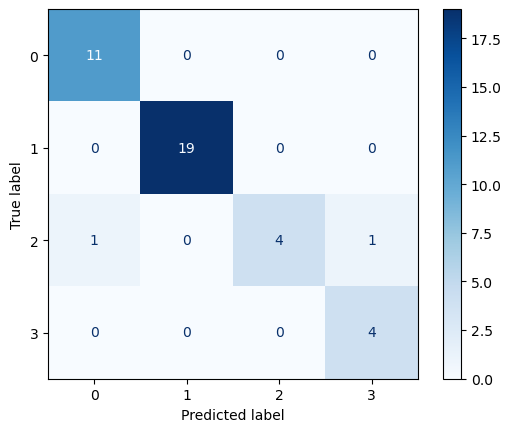

In [61]:
# Display classification report and confusion matrix for Random Forest
print("Classification Report:\n", classification_report(y_test, y_test_pred_count))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap="Blues")
plt.show()

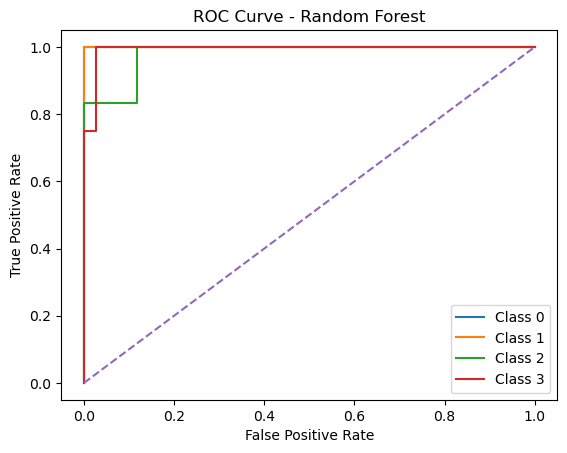

In [77]:
# Predict probability for each class for Random Forest
y_test_prob = rf.predict_proba(X_test)

# Plot ROC curve for each drug class
for i in range(y_test_prob.shape[1]):
    y_test_class = (y_test == i).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_class, y_test_prob[:, i])
    plt.plot(fpr, tpr, label='Class {}'.format(i))

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

# 5. Gradient Boosting

In [63]:
# Predict train and test labels for Gradient Boosting
y_train_pred_count = gb.predict(X_train)
y_test_pred_count = gb.predict(X_test)

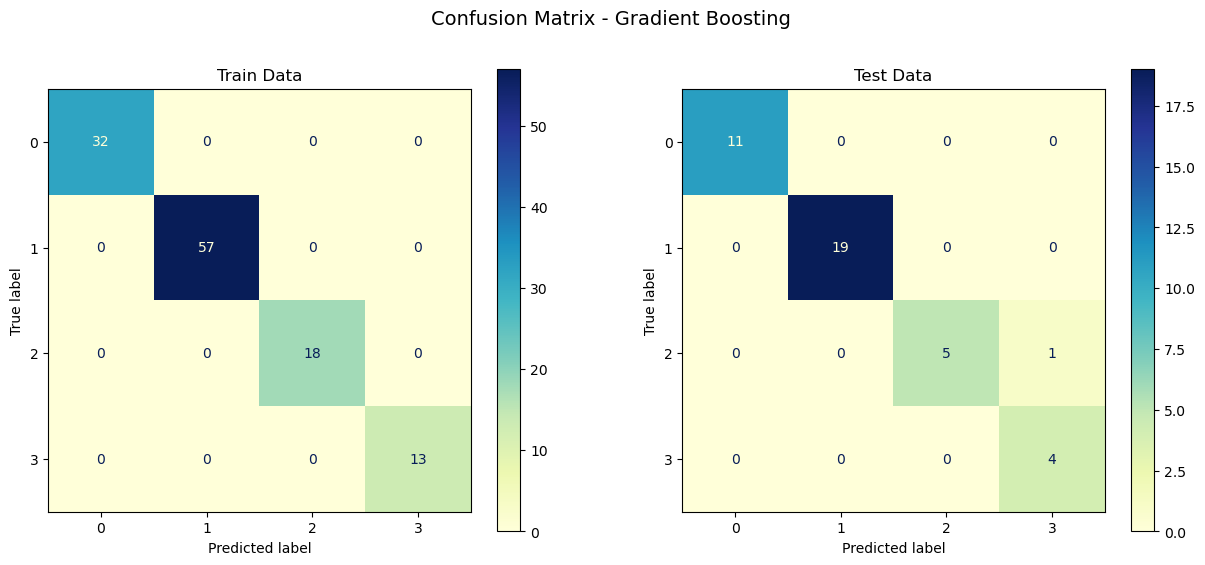

In [64]:
# Create confusion matrices for train and test data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax1)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax2)
ax1.set_title('Train Data', size=12)
ax2.set_title('Test Data', size=12)
ax1.grid(False)
ax2.grid(False)
plt.suptitle('Confusion Matrix - Gradient Boosting', size=14)
plt.show()

In [65]:
# Calculate the accuracy of Gradient Boosting on test data
print("Accuracy score for test data using Gradient Boosting is:", accuracy_score(y_test, y_test_pred_count))

Accuracy score for test data using Gradient Boosting is: 0.975


In [66]:
# Generate classification report for Gradient Boosting
train_report = classification_report(y_train, y_train_pred_count)
test_report = classification_report(y_test, y_test_pred_count)

print("Train Data Report")
print(train_report)

print("Test Data Report")
print(test_report)

Train Data Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        13

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Test Data Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19
           2       1.00      0.83      0.91         6
           3       0.80      1.00      0.89         4

    accuracy                           0.97        40
   macro avg       0.95      0.96      0.95        40
weighted avg       0.98      0.97      0.98        40



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19
           2       1.00      0.83      0.91         6
           3       0.80      1.00      0.89         4

    accuracy                           0.97        40
   macro avg       0.95      0.96      0.95        40
weighted avg       0.98      0.97      0.98        40



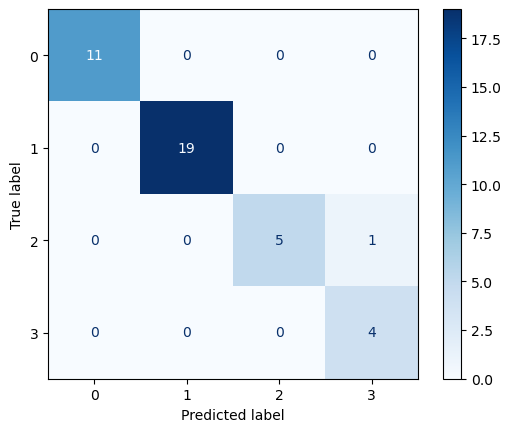

In [67]:
# Display classification report and confusion matrix for Gradient Boosting
print("Classification Report:\n", classification_report(y_test, y_test_pred_count))
ConfusionMatrixDisplay.from_estimator(gb, X_test, y_test, cmap="Blues")
plt.show()

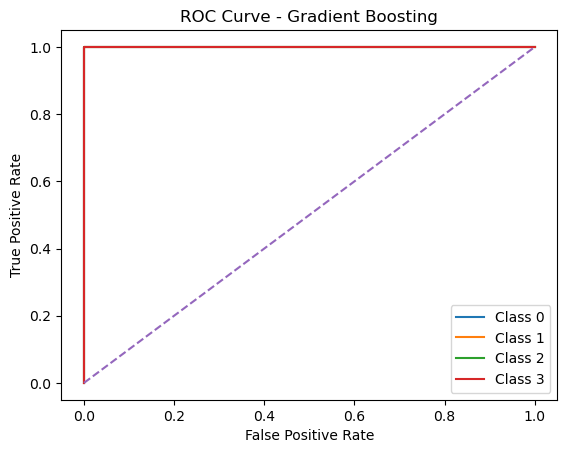

In [76]:
# Predict probability for each class for Gradient Boosting
y_test_prob = gb.predict_proba(X_test)

# Plot ROC curve for each drug class
for i in range(y_test_prob.shape[1]):
    y_test_class = (y_test == i).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_class, y_test_prob[:, i])
    plt.plot(fpr, tpr, label='Class {}'.format(i))

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()
plt.show()

# 6. KNN

In [69]:
# Predict train and test labels for KNN
y_train_pred_count = knn.predict(X_train)
y_test_pred_count = knn.predict(X_test)

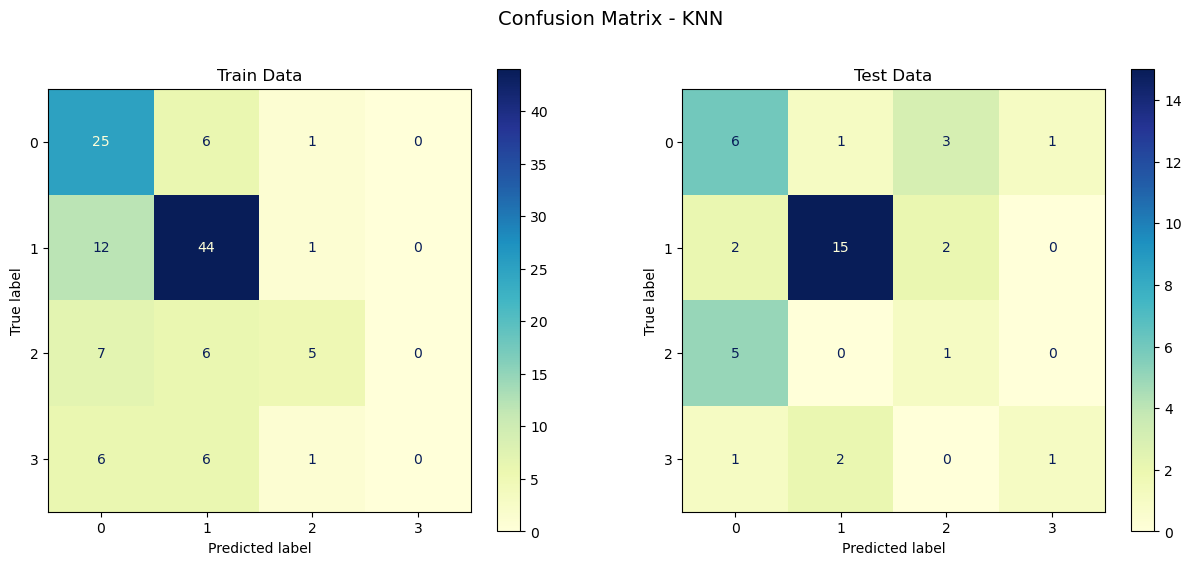

In [70]:
# Create confusion matrices for train and test data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax1)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_count, values_format='.5g', cmap='YlGnBu', ax=ax2)
ax1.set_title('Train Data', size=12)
ax2.set_title('Test Data', size=12)
ax1.grid(False)
ax2.grid(False)
plt.suptitle('Confusion Matrix - KNN', size=14)
plt.show()

In [71]:
# Calculate the accuracy of KNN on test data
print("Accuracy score for test data using KNN is:", accuracy_score(y_test, y_test_pred_count))

Accuracy score for test data using KNN is: 0.575


In [72]:
# Generate classification report for KNN
train_report = classification_report(y_train, y_train_pred_count)
test_report = classification_report(y_test, y_test_pred_count)

print("Train Data Report")
print(train_report)

print("Test Data Report")
print(test_report)

Train Data Report
              precision    recall  f1-score   support

           0       0.50      0.78      0.61        32
           1       0.71      0.77      0.74        57
           2       0.62      0.28      0.38        18
           3       0.00      0.00      0.00        13

    accuracy                           0.62       120
   macro avg       0.46      0.46      0.43       120
weighted avg       0.56      0.62      0.57       120

Test Data Report
              precision    recall  f1-score   support

           0       0.43      0.55      0.48        11
           1       0.83      0.79      0.81        19
           2       0.17      0.17      0.17         6
           3       0.50      0.25      0.33         4

    accuracy                           0.57        40
   macro avg       0.48      0.44      0.45        40
weighted avg       0.59      0.57      0.58        40



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.55      0.48        11
           1       0.83      0.79      0.81        19
           2       0.17      0.17      0.17         6
           3       0.50      0.25      0.33         4

    accuracy                           0.57        40
   macro avg       0.48      0.44      0.45        40
weighted avg       0.59      0.57      0.58        40



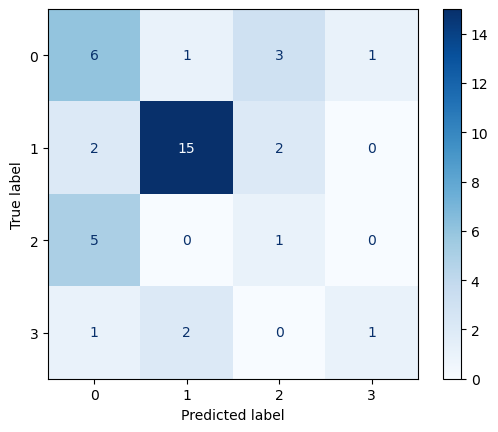

In [73]:
# Display classification report and confusion matrix for KNN
print("Classification Report:\n", classification_report(y_test, y_test_pred_count))
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, cmap="Blues")
plt.show()

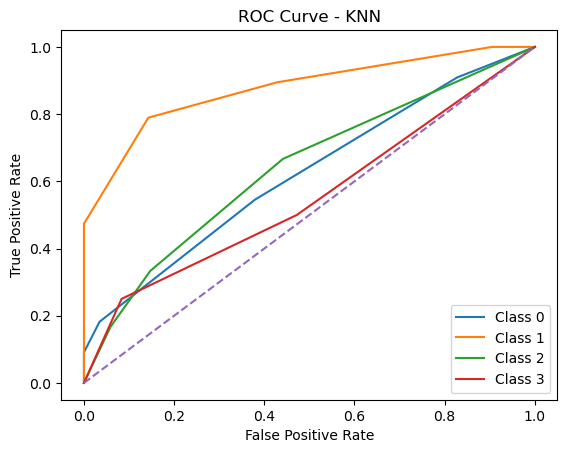

In [75]:
# Predict probability for each class for KNN
y_test_prob = knn.predict_proba(X_test)

# Plot ROC curve for each drug class
for i in range(y_test_prob.shape[1]):
    y_test_class = (y_test == i).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_class, y_test_prob[:, i])
    plt.plot(fpr, tpr, label='Class {}'.format(i))

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.show()